In [1]:
%load_ext autoreload
%autoreload 2

In [51]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import warnings; warnings.simplefilter('ignore')
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_visualize
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_models
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg
import pygtc
import jsm_simload

In [3]:
# fid500 = jsm_ancillary.load_massspec("../../data/Nparticle/N500/", "artificial", 0, conctype="zhao")

# satgen500 = fid500[fid500["logMvir"] > 12.5]
# satgen500 = satgen500.sort_values("logMvir")
# satgen500 = satgen500[satgen500["Nsub"] >= 1]

# satgen500.to_csv("../../data/summary_tabs/satgen500_art_zhao.csv")

In [4]:
# fid500 = jsm_ancillary.load_massspec("../../data/Nparticle/N500/", "artificial", 0, conctype="vdb")

# satgen500 = fid500[fid500["logMvir"] > 12.5]
# satgen500 = satgen500.sort_values("logMvir")
# satgen500 = satgen500[satgen500["Nsub"] >= 1]

# satgen500.to_csv("../../data/summary_tabs/satgen500_art_vdb.csv")

In [5]:
zhao = pd.read_csv("../../data/summary_tabs/concentrations/satgen500_art_zhao.csv")

vdb = pd.read_csv("../../data/summary_tabs/concentrations/satgen500_art_vdb.csv")

In [9]:
cols = ["log1pz50", "logc", "logNsub", "logfsub", "logMMs"]

zhao_short = (
    zhao[cols]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

vdb_short = (
    vdb[cols]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

In [30]:
np.max((10**zhao["logMMs"])*(10**zhao["logMvir"]).values)

48692990929714.6

In [31]:
np.log10(48692990929714.6)

13.687466451571499

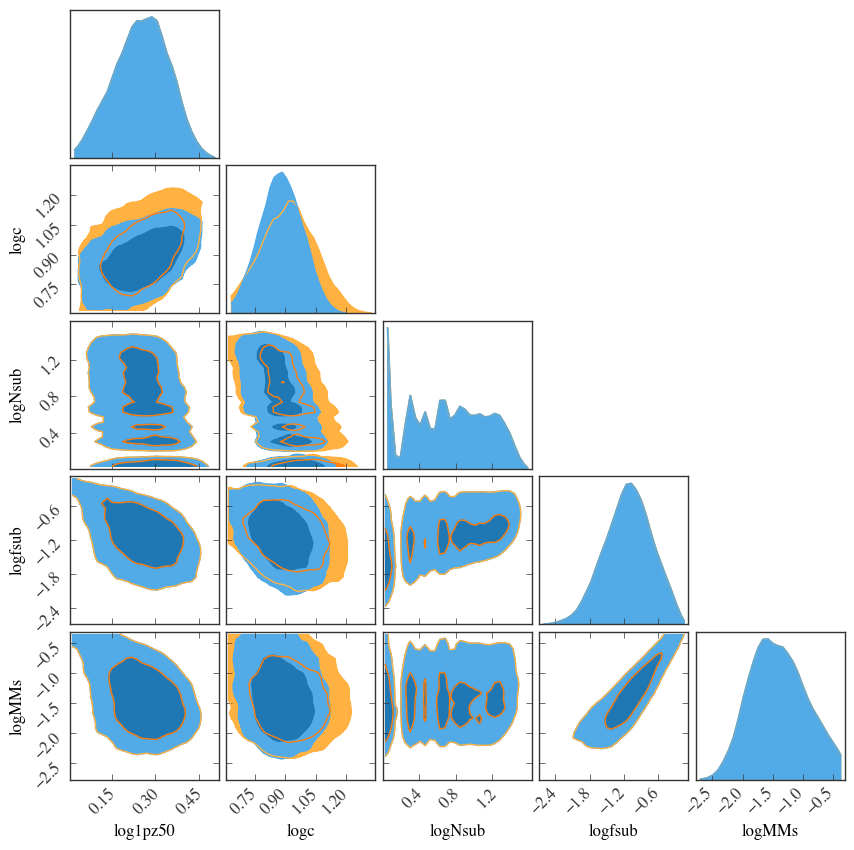

In [12]:
# corner plot
corner_comp = pygtc.plotGTC(
    chains=[vdb_short, zhao_short],
    figureSize=10,
    customTickFont={'family':'Times', 'size':12},
    customLegendFont={'family':'Times', 'size':12},
    customLabelFont={'family':'Times', 'size':12},
    mathTextFontSet=None,
    panelSpacing='loose')

In [123]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

In [124]:
satgen500 = pd.read_csv("../../data/summary_tabs/satgen500_art.csv")
satnorm = jsm_simload.NormalizeData(satgen500, dataset_title="SatGen")
# satnorm.plot_bestfit("../../figures/satgen_fit.pdf", col="C0")

In [125]:
satnorm.b_log1pz50

0.9279735786828878

In [138]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# =====================================================
# Mass grid (>50 values as requested)
# =====================================================

logM = np.linspace(12.4, 14.1, 100)
Mvir = 10**logM

# =====================================================
# Approximate points digitized by eye from figure
# =====================================================

xpts = np.array([8, 10, 12, 14, 16])

models = {

    "Lacey & Cole 93": {
        "y": np.array([1.20, 0.95, 0.67, 0.38, 0.14]),
        "style": dict(color="#b3b437", lw=2)
    },

    # "Giocoli+12": {
    #     "y": np.array([2.00, 1.55, 1.08, 0.60, 0.26]),
    #     "style": dict(color="0.55", lw=2)
    # },

    "van den Bosch et al. 14": {
        "y": np.array([2.10, 1.65, 1.15, 0.64, 0.25]),
        "style": dict(color="C0", lw=2, ls="--")
    },

    # "van den Bosch+14, modified": {
    #     "y": np.array([1.92, 1.48, 1.03, 0.58, 0.24]),
    #     "style": dict(color="#c94138", lw=2, ls="--")
    # },

    "Correa et al. 15": {
        "y": np.array([1.65, 1.47, 1.24, 0.95, 0.60]),
        "style": dict(color="#8b68b8", lw=2,)
    },

    "Bera & Diemer 26": {
        "y": np.array([1.90, 1.45, 1.00, 0.55, 0.22]),
        "style": dict(color="darkgreen", lw=2)
    },
}

# =====================================================
# Interpolate and plot
# =====================================================


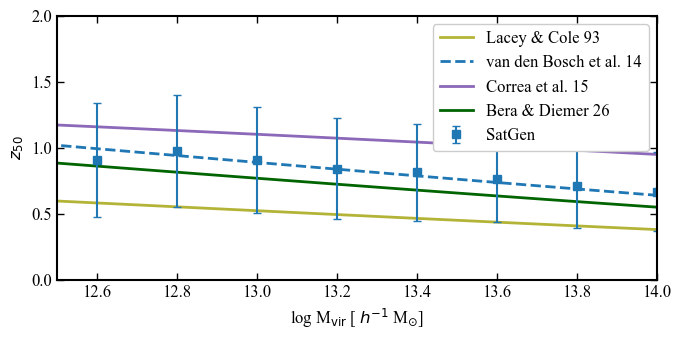

In [139]:
fig, ax = plt.subplots(figsize=(double_textwidth, single_textwidth))

for name, model in models.items():

    spline = interp1d(
        xpts,
        model["y"],
        kind="cubic"
    )

    zf = spline(logM)

    ax.plot(
        logM,
        zf,
        label=name,
        **model["style"]
    )

# ax.scatter(satnorm.df["logMvir"], 10**(satnorm.df["log1pz50"]) - 1, marker=".", s=1, alpha=0.5)
ax.errorbar(satnorm.logMvir_bincenters, satnorm.z50_med, yerr=satnorm.z50_std, marker="s", c="C0", label="SatGen", fmt="s", capsize=3)

ax.set_xlim(12.5, 14.0)
ax.set_ylim(0, 2)

ax.set_ylabel("$z_{50}$")
ax.set_xlabel("log M$_{\\rm vir}$ [$\>h^{-1}$ M$_{\\odot}$]")
ax.legend(framealpha=1)

plt.tight_layout()
plt.savefig("../../figures/z50_Mvir.pdf")